# Satellogic Processing Workflow (Testing/Import Version)

> **Dev/Testing Version:** This notebook uses Python imports instead of CLI subprocess calls.
> For the production Hub version, see `notebooks/satellogic_workflow.ipynb`.

## Workflow
1. Configure processing parameters
2. Retrieve Satellogic resources
3. Generate products (truecolor, colorIR, NDVI, NDWI)
4. Convert to COG
5. View results

## Step 1: Setup and Configuration

In [1]:
import sys
import os
from pathlib import Path

# Find repo root
repo_root = Path('.').resolve()
for _ in range(5):
    if (repo_root / 'shared_utils').is_dir():
        break
    repo_root = repo_root.parent
sys.path.insert(0, str(repo_root))

print(f"Repo root: {repo_root}")

Repo root: /home/jovyan/disasters-product-algorithms


In [2]:
# ========================================
# CONFIGURATION
# ========================================

# Event / Metadata
EVENT_NAME = '202406_Example_Event'    # Activation event name
ACTIVATION_METADATA = {
    "ACTIVATION_EVENT": EVENT_NAME,
    "SOURCE": "CSDA",
    "PROCESSOR": "NASA Disasters COG Processor v1.0",
    # YEAR_MONTH, HAZARD, LOCATION auto-parsed from EVENT_NAME
    # Add any custom key-value pairs here
}

# Satellogic Parameters
DATE = "2024-06-01 12:00:00"           # Target date (YYYY-MM-DD HH:MM:SS)
LEVEL = "L1D_SR_MS"                    # Processing level
PRODUCTS = ["colorir"]                  # Options: truecolor, ndvi, ndwi, colorir
OUTPUT_DIR = "/tmp/satellogic_output"

# COG Options
COMPRESSION = "ZSTD"
COMPRESSION_LEVEL = 22
NODATA = 0
# Target CRS for the output COG.
# None preserves the source projection (fastest, no warp).
# Uncomment the EPSG:3857 line if you plan to push the COG through
# veda-data-airflow's build_stac, which trips on the EPSG:4326 ensemble.
TARGET_CRS = None
# TARGET_CRS = "EPSG:3857"

# S3 Upload (optional)
UPLOAD_TO_S3 = False
BUCKET = 'nasa-disasters'
DESTINATION_BASE = 'drcs_activations_new'

os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Configuration:")
print(f"  Event: {EVENT_NAME}")
print(f"  Source: {ACTIVATION_METADATA.get('SOURCE', 'N/A')}")
print(f"  Date: {DATE}")
print(f"  Level: {LEVEL}")
print(f"  Products: {PRODUCTS}")
print(f"  Output: {OUTPUT_DIR}")
print(f"  Compression: {COMPRESSION} (level {COMPRESSION_LEVEL})")
print(f"  Target CRS: {TARGET_CRS if TARGET_CRS else 'Keep original'}")
print(f"  Upload to S3: {UPLOAD_TO_S3}")

Configuration:
  Event: 202406_Example_Event
  Source: CSDA
  Date: 2024-06-01 12:00:00
  Level: L1D_SR_MS
  Products: ['colorir']
  Output: /tmp/satellogic_output
  Compression: ZSTD (level 22)
  Target CRS: Keep original
  Upload to S3: False


## Step 2: Retrieve Satellogic Resources

In [3]:
from satellogic import (
    retrieve_satellogic_resources,
    genTrueColor,
    gencolorIR,
    genNDVI,
    genNDWI,
)

print("Retrieving Satellogic resources...")
metadata, tifs = retrieve_satellogic_resources(DATE, LEVEL)

print(f"Metadata keys: {list(metadata.keys()) if isinstance(metadata, dict) else type(metadata)}")
print(f"TIF files: {len(tifs) if hasattr(tifs, '__len__') else tifs}")
print(tifs)

Retrieving Satellogic resources...
Metadata keys: <class 'list'>
TIF files: 3
['s3://csda-data-vendor-satellogic/disasters/20260127_205119_326_SN41_L1D_SR_MS_341273/rasters/20260127_205119_326_SN41_L1D_SR_MS_CLOUD_0.tif', 's3://csda-data-vendor-satellogic/disasters/20260127_205119_326_SN41_L1D_SR_MS_341273/rasters/20260127_205119_326_SN41_L1D_SR_MS_TOA_0.tif', 's3://csda-data-vendor-satellogic/disasters/20260127_205119_326_SN41_L1D_SR_MS_341273/rasters/20260127_205119_326_SN41_L1D_SR_MS_VISUAL_0.tif']


## Step 3: Generate Products

In [4]:
# Map product names to generator functions
PRODUCT_FUNCTIONS = {
    'truecolor': genTrueColor,
    'colorir': gencolorIR,
    'ndvi': genNDVI,
    'ndwi': genNDWI,
}

generated_files = []

for product in PRODUCTS:
    gen_func = PRODUCT_FUNCTIONS.get(product)
    if gen_func is None:
        print(f"Unknown product: {product}")
        continue

    print(f"\nGenerating {product}...")
    outfile = gen_func(tifs, metadata, OUTPUT_DIR)

    if outfile:
        print(f"  Generated: {outfile}")
        generated_files.append(outfile)
    else:
        print(f"  Failed to generate {product}")

print(f"\nGenerated {len(generated_files)} file(s)")


Generating colorir...
Detected processing level: L1D
Using default scale factor: 0.0001
Skipping solar correction for L1D.


/home/jovyan/disasters-product-algorithms/satellogic/satellogic_v2.py:229: RuntimeWarning: invalid value encountered in cast
  out_img = (rgb * 255).astype(np.uint8)


  Generated: /tmp/satellogic_output/20260127_Satellogic_L1D_colorir2026-01-27T20:51:19Z.tif

Generated 1 file(s)


## Step 4: Convert to COG

In [5]:
from shared_utils.cog_utils import convert_to_cog, validate_cog, rename_with_event
from shared_utils.cog_metadata import resolve_metadata

# Build metadata (auto-parses YEAR_MONTH, HAZARD, LOCATION from EVENT_NAME)
file_metadata = resolve_metadata('', mode='manual', manual_metadata=ACTIVATION_METADATA)
print("Metadata that will be embedded:")
for k, v in file_metadata.items():
    print(f"  {k}: {v}")

cog_files = []

for outfile in generated_files:
    print(f"\nConverting to COG: {os.path.basename(outfile)}")

    # Rename with event name
    renamed = rename_with_event(outfile, EVENT_NAME)
    print(f"  Renamed: {os.path.basename(renamed)}")

    cog_path = convert_to_cog(
        renamed,
        nodata=NODATA,
        dst_crs=TARGET_CRS,
        compression=COMPRESSION,
        compression_level=COMPRESSION_LEVEL,
    )
    print(f"  COG created: {cog_path}")

    # Validate
    is_valid, details = validate_cog(cog_path)
    print(f"  Valid COG: {is_valid}")
    cog_files.append(cog_path)

print(f"\n{len(cog_files)} COG(s) created")

Metadata that will be embedded:
  ACTIVATION_EVENT: 202406_Example_Event
  SOURCE: CSDA
  PROCESSOR: NASA Disasters COG Processor v1.0
  YEAR_MONTH: 202406
  HAZARD: Example
  LOCATION: Event

Converting to COG: 20260127_Satellogic_L1D_colorir2026-01-27T20:51:19Z.tif
  Renaming: 20260127_Satellogic_L1D_colorir2026-01-27T20:51:19Z.tif
        to: 202406_Example_Event_Satellogic_L1D_colorir2026-01-27T20:51:19Z_2026-01-27_day.tif
  Renamed: 202406_Example_Event_Satellogic_L1D_colorir2026-01-27T20:51:19Z_2026-01-27_day.tif
  Data type: uint8
  No-data value: 0
  Source CRS: EPSG:32616
  Compression: ZSTD (level 22)
  Overview levels: 5
  Creating COG: 202406_Example_Event_Satellogic_L1D_colorir2026-01-27T20:51:19Z_2026-01-27_day.tif.cog.tmp.tif
  ✓ COG created: 202406_Example_Event_Satellogic_L1D_colorir2026-01-27T20:51:19Z_2026-01-27_day.tif
  COG created: /tmp/satellogic_output/202406_Example_Event_Satellogic_L1D_colorir2026-01-27T20:51:19Z_2026-01-27_day.tif
  Valid COG: True

1 COG(s) 

## Step 5: Upload to S3 (Optional)

Set `UPLOAD_TO_S3 = True` in Step 1 to enable.

In [6]:
if UPLOAD_TO_S3:
    from shared_utils.s3_operations import initialize_s3_client, upload_to_s3

    s3_client, _ = initialize_s3_client(bucket_name=BUCKET)

    for cog_path in cog_files:
        filename = os.path.basename(cog_path)
        s3_key = f"{DESTINATION_BASE}/Satellogic/{filename}"
        print(f"Uploading: {filename} -> s3://{BUCKET}/{s3_key}")
        upload_to_s3(s3_client, cog_path, BUCKET, s3_key)

    print(f"\n{len(cog_files)} file(s) uploaded")
else:
    print("S3 upload disabled. Set UPLOAD_TO_S3 = True in Step 1 to enable.")

S3 upload disabled. Set UPLOAD_TO_S3 = True in Step 1 to enable.


## Step 6: View Results


Displaying: 202406_Example_Event_Satellogic_L1D_colorir2026-01-27T20:51:19Z_2026-01-27_day.tif
  CRS: EPSG:32616
  Shape: (24005, 24005)
  Bands: 3
  Nodata: 0.0


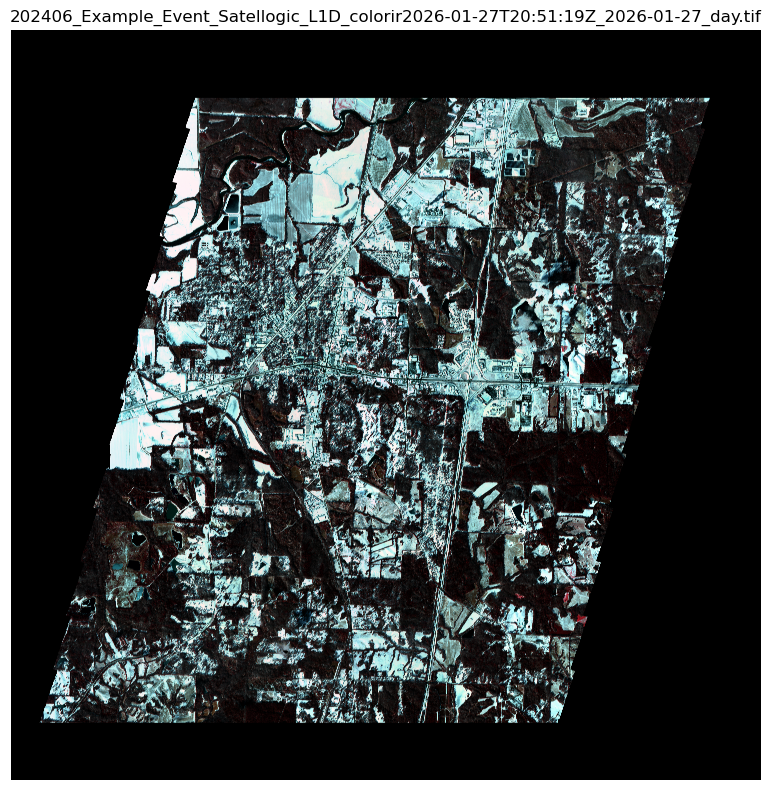


Displaying: 202601_Satellogic_L1D_colorir2026-01-27T20:51:19Z.tif
  CRS: EPSG:32616
  Shape: (24005, 24005)
  Bands: 3
  Nodata: None


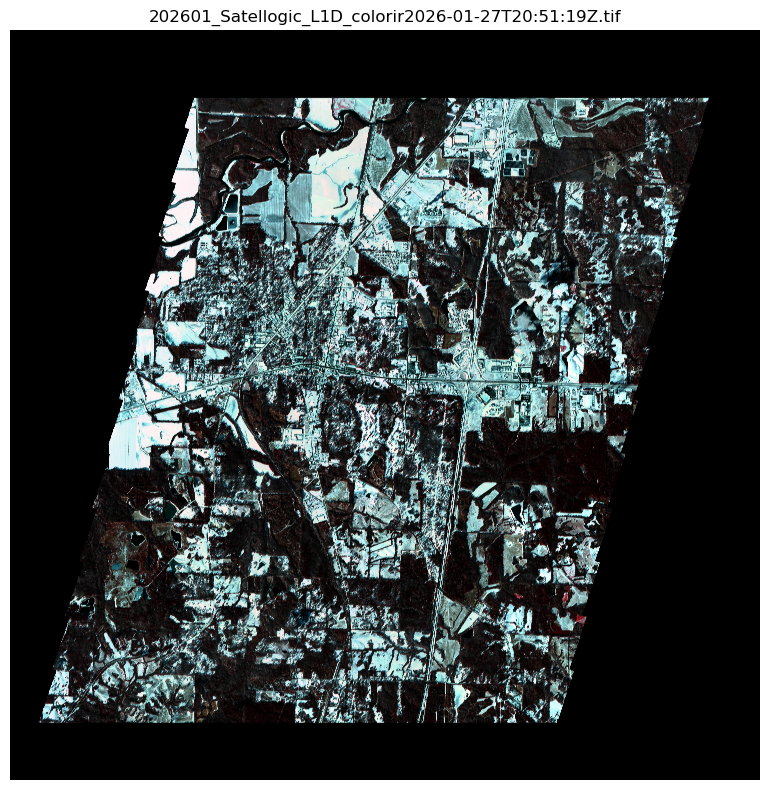


File Details:
  202406_Example_Event_Satellogic_L1D_colorir2026-01-27T20:51:19Z_2026-01-27_day.tif (749.6 MB)
  202601_Satellogic_L1D_colorir2026-01-27T20:51:19Z.tif (1648.8 MB)


In [7]:
import glob
import rasterio
import matplotlib.pyplot as plt
import numpy as np

tif_files = sorted([
    f for f in glob.glob(os.path.join(OUTPUT_DIR, '**/*.tif'), recursive=True)
    if not f.endswith('.tmp.tif')
])

for tif_file in tif_files:
    print(f"\nDisplaying: {os.path.basename(tif_file)}")

    with rasterio.open(tif_file) as src:
        print(f"  CRS: {src.crs}")
        print(f"  Shape: {src.shape}")
        print(f"  Bands: {src.count}")
        print(f"  Nodata: {src.nodata}")

        plt.figure(figsize=(8, 8))

        if src.count >= 3:
            arr = src.read([1, 2, 3]).astype(float)
            arr = np.transpose(arr, (1, 2, 0))
            band_min = np.min(arr, axis=(0, 1))
            band_max = np.max(arr, axis=(0, 1))
            arr = (arr - band_min) / (band_max - band_min + 1e-6)
            arr = np.clip(arr, 0, 1)
            plt.imshow(arr)
        else:
            arr = src.read(1).astype(float)
            filename = os.path.basename(tif_file).lower()
            if 'ndvi' in filename:
                arr = np.where((arr < -1) | (arr > 1), np.nan, arr)
                im = plt.imshow(arr, cmap='RdYlGn', vmin=-0.5, vmax=0.5)
            elif 'ndwi' in filename:
                arr = np.where((arr < -1) | (arr > 1), np.nan, arr)
                im = plt.imshow(arr, cmap='Blues')
            else:
                im = plt.imshow(arr, cmap='viridis')
            plt.colorbar(im, fraction=0.046, pad=0.04)

        plt.title(os.path.basename(tif_file))
        plt.axis('off')
        plt.tight_layout()
        plt.show()

# File sizes
print("\nFile Details:")
print("=" * 50)
for f in tif_files:
    size_mb = os.path.getsize(f) / (1024 * 1024)
    print(f"  {os.path.basename(f):50s} ({size_mb:.1f} MB)")